# EDA Prepare

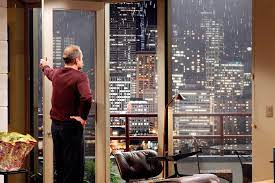

In [ ]:
# --- Import all required libraries ---
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
print("Libraries ready!")

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"})
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

Libraries ready!


## Column Names and descriptions for King County Data Set sorted by meaning
- **house_id** - unique identifier for a house
### Geographical location
- **zip** - zipcode
- **lat** - Latitude coordinate
- **long** - Longitude coordinate
### Landscape quality
- **view_quality** - quality of view
- **waterfront** - House which has a view to a waterfront
### Neighborhood quality
- **sqft_lot15** - The square footage of the land lots of the nearest 15 neighbors
- **sqft_living15** - The square footage of interior housing living space for the nearest 15 neighbors
### Footage value
- **sqft_lots** - footage of the lot - ???????????????? square?
- **price** - the latest sale price
- **sale_date** - the latest date the house was sold
### Building characteristics
- **yr_built** - Built Year
- **yr_renovated** - Year when house was renovated
- **grade** - overall grade given to the housing unit, based on King County grading system
- **condition** - How good the condition is ( Overall )
### Building footage
- **sqft_living** - footage of the home - ???????????????? square?
- **sqft_basement** - square footage of the basement
- **sqft_above** - square footage of house apart from basement
### Building details
- **floors** - floors (levels) in house
- **bedrooms** - # of bedrooms - ???????????????? not a Number
- **bathrooms** - # of bathrooms - ???????????????? not a Number

In [3]:
# --- Load the eda dataset ---
df = pd.read_csv("data/eda_test.csv")
print(f"Shape: {df.shape}")
# --- Inspect data types and missing values ---
df.info()
df.head()

Shape: (21420, 21)
<class 'pandas.DataFrame'>
RangeIndex: 21420 entries, 0 to 21419
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   house_id       21420 non-null  int64  
 1   zip            21420 non-null  int64  
 2   lat            21420 non-null  float64
 3   long           21420 non-null  float64
 4   view_quality   21357 non-null  float64
 5   waterfront     19060 non-null  float64
 6   sqft_lot15     21420 non-null  float64
 7   sqft_living15  21420 non-null  float64
 8   sqft_lot       21420 non-null  float64
 9   price          21420 non-null  float64
 10  last_sale      21420 non-null  str    
 11  yr_built       21420 non-null  int64  
 12  yr_renovated   17609 non-null  float64
 13  grade          21420 non-null  int64  
 14  condition      21420 non-null  int64  
 15  sqft_living    21420 non-null  float64
 16  sqft_basement  20969 non-null  float64
 17  sqft_above     21420 non-null  float64
 18

,house_id,zip,lat,long,view_quality,waterfront,sqft_lot15,sqft_living15,sqft_lot,price,...,yr_built,yr_renovated,grade,condition,sqft_living,sqft_basement,sqft_above,floors,bedrooms,bathrooms
0,1000102,98002,47.326,-122.214,0.000,NaN,7316.000,2060.000,9373.000,300000.000,...,1991,0.000,7,3,2400.000,0.000,2400.000,2.000,6.000,3.000
1,1200019,98166,47.444,-122.351,0.000,NaN,21891.000,2590.000,26036.000,647500.000,...,1947,0.000,8,4,2060.000,900.000,1160.000,1.000,4.000,1.750
2,1200021,98166,47.443,-122.347,0.000,0.000,20023.000,2250.000,43000.000,400000.000,...,1952,0.000,7,3,1460.000,0.000,1460.000,1.000,3.000,1.000
3,2800031,98168,47.478,-122.265,0.000,0.000,10320.000,1290.000,7599.000,235000.000,...,1930,0.000,6,4,1430.000,420.000,1010.000,1.500,3.000,1.000
4,3600057,98144,47.580,-122.294,0.000,0.000,3504.000,1480.000,3504.000,402500.000,...,1951,20130.000,7,3,1650.000,890.000,760.000,1.000,4.000,2.000


# Data cleaning
This section deals with the data set preparation:
* ordered the columns according to the information content
* fetched data without duplicates in sql query: only last sale for houses sold multiple times
* date formatting string to timestamp
* impute data without view_quality with 0 (the client does not care for that, and a better quality can be a bonus)
* increase all view_quality by +1 for better plotting
* impute data without waterfront with 0 (the client might object, waterfront reduces liveliness, but it's not feasable to draw the waterline)
* impute data without yr_renovated with yr_built (if house was yet renovated it is a bonus)
* impute data without sqft_basement or sqft_basement = 0 from other footage values: **difficult**
* check other data with 0 for adequacy


In [ ]:
# --- Check unique values in key categorical columns ---
#for col in ["house_id", "zip", "lat", "long"]:
#for col in ["view_quality", "waterfront", "sqft_lot15", "sqft_living15"]:
for col in ["grade", "condition", "floors", "bedrooms", "bathrooms"]:
#for col in ["yr_renovated", "waterfront", "view_quality"]:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(10))


yr_renovated (70 unique values):
yr_renovated
0.000        16869
20140.000       73
20130.000       31
20030.000       31
20070.000       30
20050.000       29
20000.000       29
20040.000       22
19900.000       21
20090.000       21
Name: count, dtype: int64

waterfront (2 unique values):
waterfront
0.000    18914
1.000      146
Name: count, dtype: int64

view_quality (5 unique values):
view_quality
0.000    19253
2.000      956
3.000      505
1.000      329
4.000      314
Name: count, dtype: int64


In [ ]:
# --- Check unique values ---
print(df.duplicated().value_counts())
# now house_id is unique
print(f"\n{'house_id'} ({df['house_id'].nunique()} unique values):")
print(df["house_id"].value_counts().head(10))

False    21420
Name: count, dtype: int64

house_id (21420 unique values):
house_id
1000102    1
1200019    1
1200021    1
2800031    1
3600057    1
3600072    1
3800008    1
5200087    1
6200017    1
7200080    1
Name: count, dtype: int64


## Missing values

In [6]:
# --- Check for missing data ---
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


yr_renovated     3811
waterfront       2360
sqft_basement     451
view_quality       63
dtype: int64

### Testing

In [20]:
# imputing missing or yr_renovated == 0 values by mapping yr_built
df_renovated = df
for idx in df_renovated.index:
    if pd.isna(df_renovated.at[idx, 'yr_renovated']) or df_renovated.at[idx, 'yr_renovated'] == 0:
        df_renovated.at[idx, 'yr_renovated'] = df_renovated.at[idx, 'yr_built']
# imputing missing waterfront values with 0
df_waterfront = df_renovated
for idx in df_waterfront.index:
    if pd.isna(df_waterfront.at[idx, 'waterfront']):
        df_waterfront.at[idx, 'waterfront'] = 0
# imputing missing view_quality values with 0
df_view_quality_0 = df_waterfront
for idx in df_view_quality_0.index:
    if pd.isna(df_view_quality_0.at[idx, 'view_quality']):
        df_view_quality_0.at[idx, 'view_quality'] = 0
# changing view_quality to += 1
df_view_quality = df_view_quality_0
df_view_quality.loc[df_view_quality['view_quality'] == 4, 'view_quality'] = 5
df_view_quality.loc[df_view_quality['view_quality'] == 3, 'view_quality'] = 4
df_view_quality.loc[df_view_quality['view_quality'] == 2, 'view_quality'] = 3
df_view_quality.loc[df_view_quality['view_quality'] == 1, 'view_quality'] = 2
df_view_quality.loc[df_view_quality['view_quality'] == 0, 'view_quality'] = 1

missing = df_view_quality.isna().sum().sort_values(ascending=False)
missing[missing > 0]
    


Series([], dtype: int64)

 ### Dealing with sqft_basement is null or sqft_basement = 0
Findings for sqft_basement:
* values can be missing or 0
* relevant also for floors >= 2 meaning the basement has no living space, thus a basement floor does not add value but area might be lively
* counted 12.999 houses with sqft_living <= sqft_above
* counted 12.717 houses with sqft_basement = 0
    * of which 6.106 houses with floors < 2
* counted **451** houses with sqft_basement is null
* **none** of the affected houses have sqft_living < sqft_above
* **all** **5361** houses with 1 floor and sqft_basement => 0 data fulfill the condition sqft_living = sqft_basement + sqft_above

Conclusions:
* more than half of the houses have no living space in the basement
* a descision is needed only for 2% of the dataset with sqft_basement **is null**
* reason is **sqft_living<=sqft_above+sqft_basement**
* counted **451** houses with sqft_basement is null
    * of which **169** houses with sqft_living > sqft_above: **solution** sqft_basement = sqft_living - sqft_above
    * of which **282** houses with sqft_living = sqft_above: **solution** sqft_basement = 0
* checking for consistency: **none** where (sqft_basement is not null) and sqft_living != sqft_basement + sqft_above
* data with sqft_basement = 0 is **assumed** to be correct

Result:
With the data imputation for sqft_basement is null the data is consistent, basement without living space is common and assigned a 0 value.

In [21]:
# imputing missing sqft_basement values as described above
df_basement = df_view_quality
for idx in df_basement.index:
    if pd.isna(df_basement.at[idx, 'sqft_basement']):
        if df_basement.at[idx, 'sqft_living'] > df_basement.at[idx, 'sqft_above']:
            df_basement.at[idx, 'sqft_basement'] = df_basement.at[idx, 'sqft_living'] - df_basement.at[idx, 'sqft_above']
        else: df_basement.at[idx, 'sqft_basement'] = 0

missing = df_basement.isna().sum().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: int64)

In [22]:
# saving the cleaned data
df_basement.to_csv("data/eda_clean.csv", index=False)

In [23]:
#test cleaned data
df = pd.read_csv("data/eda_clean.csv")
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]
for col in ["yr_renovated", "waterfront", "view_quality"]:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(10))


yr_renovated (185 unique values):
yr_renovated
2014.000    559
2006.000    453
2005.000    450
2004.000    429
2003.000    419
2007.000    415
1977.000    408
1978.000    381
2008.000    367
1968.000    363
Name: count, dtype: int64

waterfront (2 unique values):
waterfront
0.000    21274
1.000      146
Name: count, dtype: int64

view_quality (5 unique values):
view_quality
1.000    19316
3.000      956
4.000      505
2.000      329
5.000      314
Name: count, dtype: int64


## Further cleaning
* change to int: view_quality, waterfront, bedrooms
* yr_renovated **has** **bugs**; also to int

In [ ]:
# check for decimals and ormatting to int
try:
    df['view_quality'] = df['view_quality'].astype(int)
except ValueError as e:
    raise ValueError("view_quality codes contain non-integer values") from e
try:
    df['bedrooms'] = df['bedrooms'].astype(int)
except ValueError as e:
    raise ValueError("bedrooms codes contain non-integer values") from e
try:
    df['waterfront'] = df['waterfront'].astype(int)
except ValueError as e:
    raise ValueError("waterfront codes contain non-integer values") from e
try:
    df['yr_renovated'] = df['yr_renovated'].astype(int)
except ValueError as e:
    raise ValueError("yr_renovated codes contain non-integer values") from e

for col in ["bedrooms", "waterfront", "view_quality", "yr_renovated"]:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(10))



bedrooms (12 unique values):
bedrooms
3     9731
4     6849
2     2736
5     1586
6      265
1      191
7       38
8       13
9        6
10       3
Name: count, dtype: int64

waterfront (2 unique values):
waterfront
0    21274
1      146
Name: count, dtype: int64

view_quality (5 unique values):
view_quality
1    19316
3      956
4      505
2      329
5      314
Name: count, dtype: int64

yr_renovated (185 unique values):
yr_renovated
2014    559
2006    453
2005    450
2004    429
2003    419
2007    415
1977    408
1978    381
2008    367
1968    363
Name: count, dtype: int64


In [36]:
## yr_renovated trim some rows have > 9999
df_renovated_dec = df
for idx in df_renovated_dec.index:
    if df_renovated_dec.at[idx, 'yr_renovated'] >9999:
         df_renovated_dec.at[idx, 'yr_renovated'] = df_renovated_dec.at[idx, 'yr_renovated'] /10
df['yr_renovated'] = df_renovated_dec['yr_renovated']
df_cleaning_finished = df
for col in ["yr_built", "yr_renovated"]:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(10))


yr_built (116 unique values):
yr_built
2014    559
2006    453
2005    450
2004    429
2003    420
2007    415
1977    415
1978    384
1968    379
2008    367
Name: count, dtype: int64

yr_renovated (116 unique values):
yr_renovated
2014    632
2005    479
2006    473
2004    451
2003    450
2007    445
1977    415
1978    384
2008    382
1968    370
Name: count, dtype: int64


In [43]:
# saving the cleaned data final
df_cleaning_finished.to_csv("data/eda_clean_final.csv", index=False)

In [ ]:
# Formatting Date
df_cleaning_finished["last_sale"] = pd.to_datetime(df_cleaning_finished["last_sale"], format="%Y-%m-%d")
type(df_cleaning_finished["last_sale"][0])

pandas.Timestamp

In [ ]:
df = pd.read_csv("data/eda_clean_final.csv")

In [ ]:
# Breakdown prices by season "Q1", "Q2", "Q3", "Q4"

filtered = df[
    (df["long"] >= -122.35) & (df["long"] <= -122.30) &
    (df["lat"] >= 47.6) & (df["lat"] <= 47.625)
].copy()

filtered = filtered[filtered["sqft_living"] > 0].copy()
filtered["price_per_sqft"] = filtered["price"] / filtered["sqft_living"]

filtered["last_sale"] = pd.to_datetime(filtered["last_sale"], errors="coerce")
filtered["sales_binned"] = "Q" + filtered["last_sale"].dt.quarter.astype("Int64").astype(str)

filtered = filtered[filtered["sales_binned"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()

filtered["sales_binned"] = pd.Categorical(
    filtered["sales_binned"],
    categories=["Q1", "Q2", "Q3", "Q4"],
    ordered=True
)

# Calculate q_observation just a manual visual shifted from median
q_observation = filtered["sqft_living"].median()#+140


quarter_colors = {
    "Q1": "#F72585",
    "Q2": "#AD4EAD",
    "Q3": "#2D3AB3",
    "Q4": "#527914"
}

price_distribution = sns.lmplot(
    data=filtered,
    x="sqft_living",
    y="price_per_sqft",
    hue="sales_binned",
    scatter_kws={"alpha": 0.12, "s": 10},
    height=9,
    aspect=1.3,
    palette=quarter_colors,
    legend=False
)

ax = price_distribution.ax

ax.set_xlabel("Living area in ft²", color="black", fontsize=12)
ax.set_ylabel("USD per ft²", color="black", fontsize=12)
ax.tick_params(axis="both", colors="black")

for spine in ax.spines.values():
    spine.set_color("black")

legend_handles = [
    Line2D(
        [0], [0],
        color=quarter_colors[q],
        marker="o",
        linestyle="-",
        markersize=6,
        linewidth=2,
        label=q
    )
    for q in ["Q1", "Q2", "Q3", "Q4"]
]

legend = ax.legend(
    handles=legend_handles,
    title="Sale quarter",
    loc="best",
    frameon=True
)

legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_alpha(1)

legend.get_title().set_color("black")
for text in legend.get_texts():
    text.set_color("black")

# Add vertical line at q_observation
axvline = price_distribution.ax.axvline(x=q_observation, color='green', linestyle='--', linewidth=1.5)
# Create a visible label with contrasting colors
label = axvline.get_label()
price_distribution.ax.annotate(
    f'Median: {q_observation:.1f} sqft',
    xy=(q_observation, 0), xycoords='data',
    xytext=(0, 20), textcoords='offset points',
    ha='center', color='red',  # Use contrasting color
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
)

plt.suptitle(
    "Size of living area vs. price per ft² Grouped by sale quarter \n Q4 is best for the mid-range footage",
    fontsize=14,
    fontweight="bold",
    y=1.02,
    color="black"
)

plt.tight_layout()
plt.show()
